# Supervised Learning (Classification)

 Mục tiêu
 - Dự đoán học sinh đậu / rớt
 - So sánh các mô hình
 - Đánh giá hiệu suất và phân tích lỗi

In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV

import matplotlib.pyplot as plt

print("Libraries loaded")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Data loaded")

Data loaded


## Trong bài toán phân loại này:
- F1-score được sử dụng làm metric chính (do có thể mất cân bằng lớp)
- ROC-AUC dùng để đánh giá khả năng phân biệt giữa hai lớp

## BASELINE MODEL (Logistic Regression)

In [3]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy: 0.6582278481012658
              precision    recall  f1-score   support

           0       0.47      0.35      0.40        26
           1       0.72      0.81      0.76        53

    accuracy                           0.66        79
   macro avg       0.60      0.58      0.58        79
weighted avg       0.64      0.66      0.64        79



## RANDOM FOREST MODEL

In [4]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
Accuracy: 0.6835443037974683
              precision    recall  f1-score   support

           0       0.54      0.27      0.36        26
           1       0.71      0.89      0.79        53

    accuracy                           0.68        79
   macro avg       0.63      0.58      0.57        79
weighted avg       0.65      0.68      0.65        79



## HYPERPARAMETER TUNING

In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

best_model = grid.best_estimator_

## CROSS VALIDATION (Final Model)

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

y_pred_best = best_model.predict(X_test)

print("=== Tuned Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

print("=== Model Comparison ===")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))


Best parameters: {'max_depth': None, 'n_estimators': 200}
Cross-validation scores: [0.8125     0.73913043 0.81188119 0.8        0.83870968]
Mean CV score: 0.8004442600641551
=== Tuned Random Forest ===
Accuracy: 0.6582278481012658
              precision    recall  f1-score   support

           0       0.45      0.19      0.27        26
           1       0.69      0.89      0.78        53

    accuracy                           0.66        79
   macro avg       0.57      0.54      0.52        79
weighted avg       0.61      0.66      0.61        79

=== Model Comparison ===
Logistic Regression Accuracy: 0.6582278481012658
Random Forest Accuracy: 0.6835443037974683
Tuned Random Forest Accuracy: 0.6582278481012658


- Random Forest cho kết quả tốt hơn Logistic Regression
- về cả Accuracy và F1-score, cho thấy khả năng học phi tuyến hiệu quả hơn.

## CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 5 21]
 [ 6 47]]


## Phân tích lỗi

 - False Positive: dự đoán đậu nhưng thực tế rớt
 - False Negative: dự đoán rớt nhưng thực tế đậu
 
 Trong bài toán này, False Negative quan trọng hơn,
 vì bỏ sót học sinh có nguy cơ rớt sẽ gây hậu quả lớn.
 
## Do đó, cần ưu tiên cải thiện Recall cho lớp rớt.

## ROC Curve

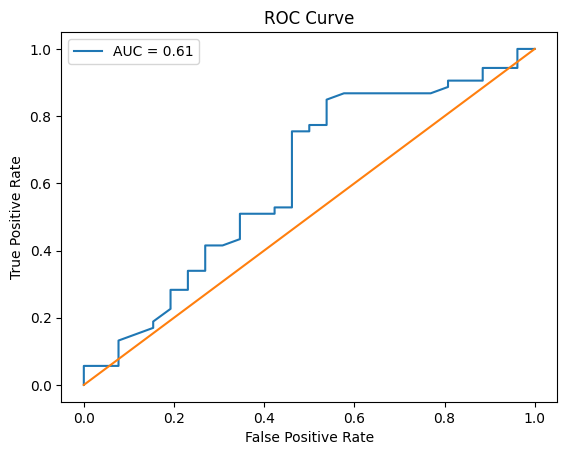

In [7]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

-  ROC Curve cho thấy khả năng phân biệt giữa hai lớp.
-  Giá trị AUC càng cao → mô hình càng tốt.

## FEATURE IMPORTANCE

     Feature  Importance
5   failures    0.100081
12  absences    0.091554
8      goout    0.054284
0        age    0.053717
11    health    0.043591
7   freetime    0.041874
2       Fedu    0.040228
10      Walc    0.040078
1       Medu    0.038652
6     famrel    0.033029


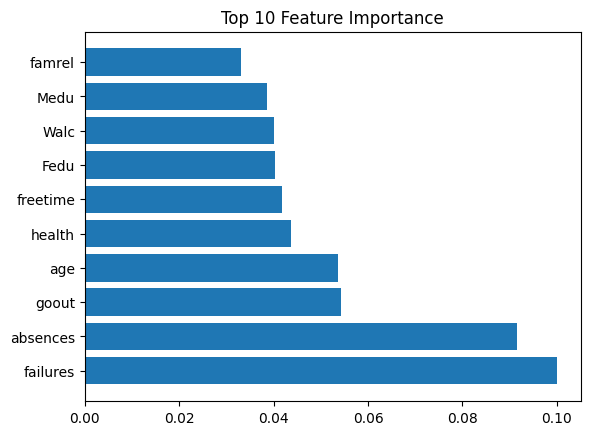

In [8]:
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.title("Top 10 Feature Importance")
plt.show()

## Insights

 1. Logistic Regression được sử dụng làm baseline để so sánh.
 
 2. Random Forest cho kết quả tốt hơn nhờ khả năng học phi tuyến.
 
 3. GridSearchCV giúp tối ưu tham số, cải thiện hiệu suất mô hình.
 
 4. Cross-validation cho thấy mô hình ổn định trên nhiều tập dữ liệu.
 
 5. Phân tích feature importance cho thấy:
 
 - failures là yếu tố quan trọng nhất → học sinh từng trượt có nguy cơ rớt rất cao
 - absences ảnh hưởng mạnh → nghỉ học nhiều làm giảm đáng kể khả năng đậu
 - studytime có tác động tích cực → học nhiều giúp tăng xác suất đậu
 
 6. Điều này cho thấy hành vi học tập (attendance, effort)
    là yếu tố quyết định kết quả học tập,
    quan trọng hơn các đặc điểm cá nhân khác.
 
 ## Ứng dụng
 
 - Dự đoán học sinh có nguy cơ rớt
 - Xây dựng hệ thống cảnh báo sớm
 - Hỗ trợ giáo viên đưa ra chiến lược can thiệp